In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
import astropy.units as u
import os
import pandas as pd
from astroquery.jplsbdb import SBDB

import phunk
from sbpy import photometry as phot
import lmfit
from scipy.interpolate import CubicSpline
from scipy import stats

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler


In [2]:
# %% Biases
filter_bias = {"B": 0.11,
              "g": -0.325,
              "c": -0.017, 
              "V": 0.085,
              "w": 0.111,
              "r": 0.126,
               "R": 0.282,
               "G" : 0.154,
               "o": 0.325,
               "i": 0.334,
               "I": 0.246,
               "z": 0.287,
               "y": 0.336,
               "Y": 0.906,
               "J": 1.362,
               "H": 1.81,
               "K": 1.835,
               "-": -0.037,
               "u": -2.436,
               "C": 0.351
              }

In [16]:
#%%
def spline(file_path):
    delimiter = None
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Initialize an empty list to store columns
    columns = []

    for line in lines:
        # Split the line by the delimiter
        values = line.strip().split(delimiter)

        # Append values to corresponding column lists
        if not columns:
            columns = [[] for _ in values]  # Initialize columns on the first row

        for i, value in enumerate(values):
            columns[i].append(float(value))
    ph = np.array(columns[0] + columns[4] + columns[8])
    phi1 = np.array(columns[1] + columns[5] + columns[9])
    phi2 = np.array(columns[2] + columns[6] + columns[10])
    phi3 = np.array(columns[3] + columns[7] + columns[11])
    
    idx = np.where(ph == 8)
    
    ph = np.delete(ph, idx[0])
    phi1 = np.delete(phi1, idx[0])
    phi2 = np.delete(phi2, idx[0])
    phi3 = np.delete(phi3, idx[0])
    
    return CubicSpline(ph, phi1), CubicSpline(ph, phi2), CubicSpline(ph, phi3)

#%%
def hg1g2_phase_function(alpha, H, G1, G2):
    """
    Calculate the apparent magnitude V of an asteroid at phase angle alpha
    using the HG1G2 phase function.

    Parameters:
    - H (float): Absolute magnitude of the asteroid.
    - G1 (float): Slope parameter 1 of the asteroid (0 ≤ G1 ≤ 1).
    - G2 (float): Slope parameter 2 of the asteroid (0 ≤ G2 ≤ 1).
    - alpha (float or array-like): Phase angle(s) in degrees.

    Returns:
    - V (float or array-like): Apparent magnitude(s) at phase angle(s) alpha.
    """
    # Convert alpha to radians
    alpha_rad = np.radians(alpha)
    
    file_path = r"C:\Users\nagai\Downloads\phases_and_phi.txt"
    cs_ph1, cs_ph2, cs_ph3 = spline(file_path)
    # Compute Phi1 and Phi2
    phi1 = cs_ph1(alpha)
    phi2 = cs_ph2(alpha)

    # Compute Phi3 using alpha in degrees
    phi3 = cs_ph3(alpha)

    # Compute the magnitude V(alpha) using the HG1G2 function
    V = H - 2.5 * np.log10(G1 * phi1 + G2 * phi2 + (1 - G1 - G2) * phi3)

    return V
#%%
def mag_area_HG1G2(results, H_val_2, G1_val, G2_val, ph_an):
    """
    Generate sampled magnitudes for the HG1G2 model considering parameter uncertainties.

    Parameters:
    - results: Fitting result object containing the covariance matrix.
    - H_val_2 (float): Best-fit absolute magnitude H.
    - G1_val (float): Best-fit slope parameter G1.
    - G2_val (float): Best-fit slope parameter G2.
    - ph_an (array-like): Phase angles in degrees.

    Returns:
    - mag_samples (ndarray): Simulated magnitudes for parameter samples and phase angles.
    """

    # Get the covariance matrix
    cov_matrix = results.covar  # Ensure this is a 3x3 matrix for [H, G1, G2]
    
    # Construct mean parameter vector
    params_mean = np.array([H_val_2, G1_val, G2_val])
    #print(cov_matrix)
    # Ensure covariance matrix shape matches parameters
    if cov_matrix.shape != (3, 3):
        raise ValueError("Covariance matrix must be 3x3 for parameters [H, G1, G2]")

    # Generate sample parameters from multivariate normal distribution
    n_samples = 3000  # Number of simulations
    samples = np.random.multivariate_normal(params_mean, cov_matrix, n_samples)

    # Initialize array to store sampled magnitudes
    mag_samples = np.zeros((n_samples, len(ph_an)))

    # Loop through samples and compute model magnitudes
    for i in range(n_samples):
        H_sample, G1_sample, G2_sample = samples[i]

        # Apply constraints to G1 and G2
        if G1_sample < 0 or G2_sample < 0 or (G1_sample + G2_sample > 1):
            continue  # Skip invalid parameter samples

        # Compute magnitudes using the HG1G2 phase function
        mag_samples[i] = hg1g2_phase_function(ph_an, H_sample, G1_sample, G2_sample)
    # Step 1: Identify rows that are not all zeros
    non_zero_rows = ~np.all(mag_samples == 0, axis=1)

    # Step 2: Filter out rows with all zeros
    filtered_data = mag_samples[non_zero_rows]
    return filtered_data
#%%
def fit(phase, mag, weights=None, method="HG", mag_errors=None, G1= None, G2 = None):
    """
    Fit a phase curve using the HG or HG1G2 model with constraints.

    Parameters:
    - phase (array-like): Phase angles.
    - mag (array-like): Observed magnitudes.
    - weights (array-like, optional): Weights for fitting. Defaults to 1/mag_errors.
    - method (str): Phase function model to use ("HG" or "HG1G2").
    - mag_errors (array-like, optional): Magnitude uncertainties. Defaults to 0.03 for all data points.

    Returns:
    - result: Fitting result object from lmfit.
    """
    # Select the appropriate model
    if method == "HG":
        model = lmfit.Model(eval_fit_HG)
    elif method == "HG1G2":
        model = lmfit.Model(eval_fit_HG1G2)
    else:
        raise ValueError("Invalid method. Use 'HG' or 'HG1G2'.")

    # Initialize parameters
    params = lmfit.Parameters()
    params.add("H", value=15, min=0, max=30)

    if method == "HG":
        params.add("G", value=0.15, min=0, max=1.0)
        #params['G'].vary = False
        
    elif method == "HG1G2":
        if G1:
            params.add("G1", value=G1, min=0, max=1.0, vary = False)    
        else:
            params.add("G1", value=0.15, min=0, max=1.0)  # Free parameter
        if G2:
            params.add("G2", value = G2, min=0, max = 1.0, vary = False)
        else:    
            print ("Not fixed")
            params.add("G2", value = 0.2, min=0, max = 1.0)        # Dependent parameter ensuring G1 + G2 <= 1

    # Set default magnitude errors if not provided
    if mag_errors is None:
        mag_errors = np.full(len(phase), 0.03)

    # Default weights if not provided
    if weights is None:
        weights = 1.0 / mag_errors

    # Perform the fit
    result = model.fit(
        mag,
        params,
        phase=phase,
        method="least_squares",
        weights=weights,
        fit_kws={"loss": "soft_l1"},
    )

    return result
#%%
def eval_fit_HG1G2(phase, H, G1, G2):
    """Evaluation function for fitting. Required for lmfit."""
    return phot.HG1G2.evaluate(np.radians(phase), H, G1,G2) 
#%%

In [10]:
def removeOutliers(xdatas, ydatas, outlierConstant):
    # Calculate the first (25th percentile) and third (75th percentile) quartiles of ydatas
    Q1, Q3 = np.percentile(ydatas, [25, 75])
    IQR = Q3 - Q1
    
    # Define the lower and upper bounds for inliers
    lower_bound = Q1 - outlierConstant * IQR
    upper_bound = Q3 + outlierConstant * IQR
    
    # Create a boolean mask for values that are within the inlier bounds
    mask = (ydatas >= lower_bound) & (ydatas <= upper_bound)
    
    # Filter xdatas and ydatas using the mask
    x_filtered = xdatas[mask]
    y_filtered = ydatas[mask]
    
    # Get the indices of the elements that are removed (i.e., outliers)
    removed_indices = np.where(~mask)[0]
    
    return x_filtered, y_filtered, removed_indices

In [229]:
df = pd.read_excel(r"C:\Users\nagai\Documents\Asteroids_BF_2\AstBFT08oj\1205-4267.xlsx")

Asteroid_list_df = df["Aster."]

All_obs = df.iloc[:, 1::2]

All_obs_cleaned = All_obs.iloc[:, :-1]
obj_names = All_obs_cleaned.columns
print (obj_names)

Index(['T08o', '703G', '703V', 'C57G', 'D29R', 'F51w', 'G45r', 'P07G', 'G96G',
       'G96V', 'I41r', 'M22o', 'T05c', 'T05o', 'T08c', 'W68o', 'I41g', 'T05w',
       'F52w', 'T08w', 'W68c', 'Q68R', 'G69R', '689V', 'Citi  '],
      dtype='object')


In [230]:
def selecting_obs(obj_names, idx):
    reduced_obs = []
    best_number = 0
    for observatories in obj_names:
        temp_obs = df[observatories]
        
        str_value = temp_obs.loc[idx]
        try:
            if str_value.iloc[-1][-1] == "+":
                reduced_obs.append(observatories)
            obs_numb = int(str_value.iloc[-1][:-1])
            if obs_numb > best_number:
                best_number = obs_numb
                best_obs = observatories
        except:
            continue
    return np.array(reduced_obs), best_obs

In [279]:
Asteroid_number = 1798
remove_obs = [""]
idx = np.where(Asteroid_list_df == Asteroid_number)
reduced_obs, best_obs = selecting_obs(obj_names, idx)
idx_remove = np.where(np.isin(reduced_obs, remove_obs))[0]
reduced_obs = np.delete(reduced_obs, idx_remove)
print (reduced_obs)
print ("Most observations: ", best_obs)

KeyError: 'T08o'

In [301]:
# For internal file
file_path = r"C:\Users\nagai\Downloads\phases_and_phi.txt"
# reference table
path = r"C:\Users\nagai\Documents\Asteroids_BF_2\AstBFT08oj\T08oBF\\"
# The name of the excel file
file_name = r"{}-excelBF.xlsx".format(Asteroid_number)
sheet_name = reduced_obs[0]
sheet_name = "P07G"

filter_name = sheet_name[-1]
# sheet_name= nosaukums worksheetam
df = pd.read_excel(path+file_name, index_col=None, sheet_name=sheet_name)
df = df.dropna(subset=['magred'])
# Reading mag (absolute mag preferably) and time
H =df["magred"]
mag = df["mag"]
time = df["epoch"]
Ph = df["Ph"]
sol_dis =df.iloc[:,3]
geo_dis = df.iloc[:,4]

H = mag - 5*np.log10(geo_dis*sol_dis)
try: 
    time_red = df["Jdc2"]
except:
    time_red = time+(sol_dis- sol_dis[0])*4.99/36/24

H = H + filter_bias[filter_name]

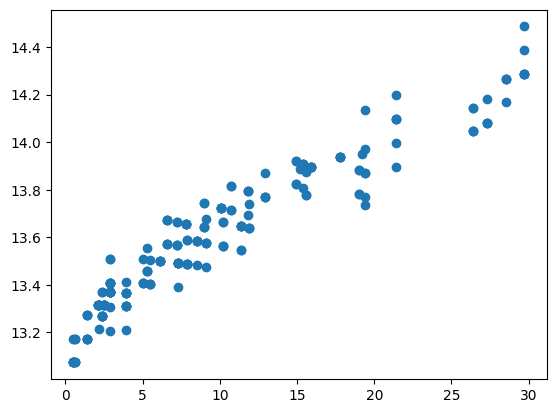

In [302]:
Ph_r, H_r, remove_idx = removeOutliers(np.array(Ph), np.array(H), 1.8)
time_idx_removed = np.delete(time_red, remove_idx)
plt.scatter(Ph, H)

Not fixed
Absolute magnitude: 13.00
G1 = 0.395, G2 = 0.2844176


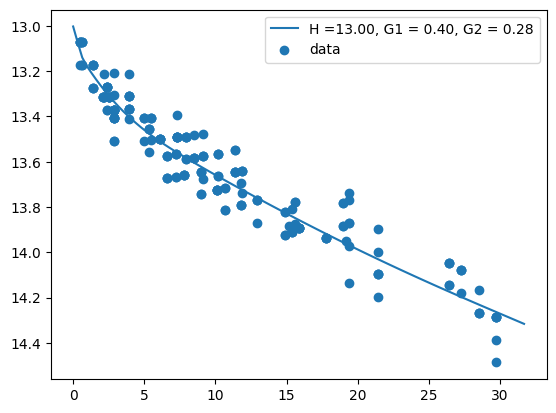

In [303]:
file_path = r"C:\Users\nagai\Downloads\phases_and_phi.txt"
ph_an = np.linspace(0, max(Ph) + 2, 100)
results2 = fit(Ph_r, H_r, method="HG1G2")

H_val_2 = results2.params["H"].value
G1_val = results2.params["G1"].value
G2_val = results2.params["G2"].value

H_err_2 = results2.params["H"].stderr or 0
G1_err = results2.params["G1"].stderr or 0
G2_err = results2.params["G2"].stderr or 0

mag_analy_2 = hg1g2_phase_function(ph_an, H_val_2, G1_val, G2_val)

mag_samples_2 = mag_area_HG1G2(results2, H_val_2, G1_val, G2_val, ph_an)

print ("Absolute magnitude: {:.2f}".format(H_val_2))
print ("G1 = {:.3f}, G2 = {:.7f}".format(G1_val, G2_val))

plt.plot(ph_an, mag_analy_2, label = "H ={:.2f}, G1 = {:.2f}, G2 = {:.2f}".format(H_val_2, G1_val, G2_val))
plt.scatter(Ph_r, H_r, label = "data")
plt.gca().invert_yaxis()
plt.legend()

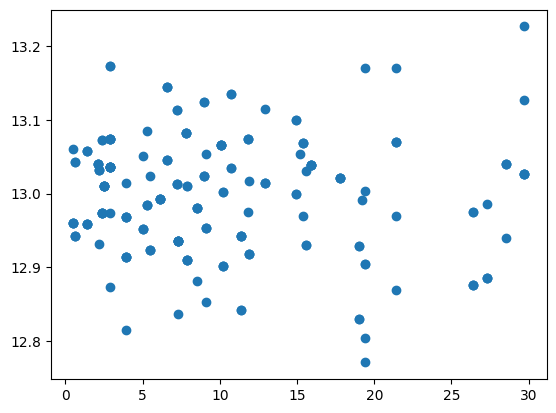

In [304]:
H_model = hg1g2_phase_function(Ph_r, H_val_2, G1_val, G2_val)

H_reduced = H_r - (H_model - H_val_2)

plt.scatter(Ph_r, H_reduced)

In [305]:
ys = H_reduced
ts = time_idx_removed
ph = Ph_r

In [306]:
import os
save_figures = r"C:\Users\nagai\Documents\Figures for aster periods\\"
new_dir_path = save_figures + "{}\{}\\".format(Asteroid_number,sheet_name)
save_figures = new_dir_path
os.mkdir(new_dir_path)

In [308]:

# Lomb scargle periodgramma
ls = LombScargle(ts, ys, nterms=2)
# frequency, power = ls.autopower(minimum_frequency=0.5, maximum_frequency=20,
#                                 samples_per_peak=10)

# frekvenču spektrs 
#frequency, power = ls.autopower(minimum_frequency=1/(7.5/24), maximum_frequency=1/(3/24),samples_per_peak=50)
frequency, power = ls.autopower(minimum_frequency=1/(8/24), maximum_frequency=1/(1.2/24),samples_per_peak=50)

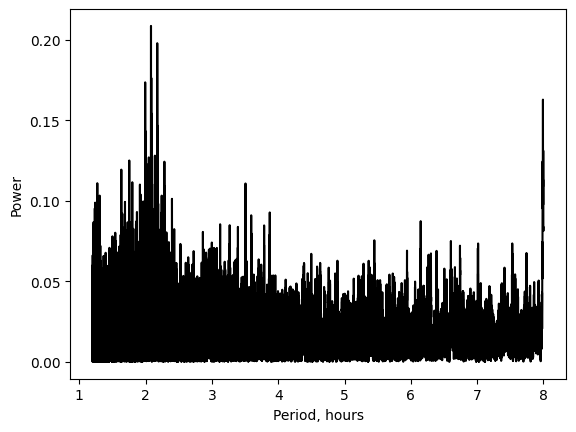

In [309]:
# Frekvenču spektra attēloshana grafiski
plt.plot(1/frequency*24, power, c="black")
# plt.scatter(1/(database_period/24), 1)
# plt.ylim((0,4))
plt.xlabel(r"Period, hours")
plt.ylabel("Power")
plt.savefig(save_figures + "{}_power_spectrum_full".format(Asteroid_number))


In [290]:
# Making a dataframe so it is easier to manipulate with data
df_results = pd.DataFrame({"freq": frequency, "power": power})
df_results = df_results.sort_values(
    by=["power"], ascending=False, ignore_index=True)
# %%

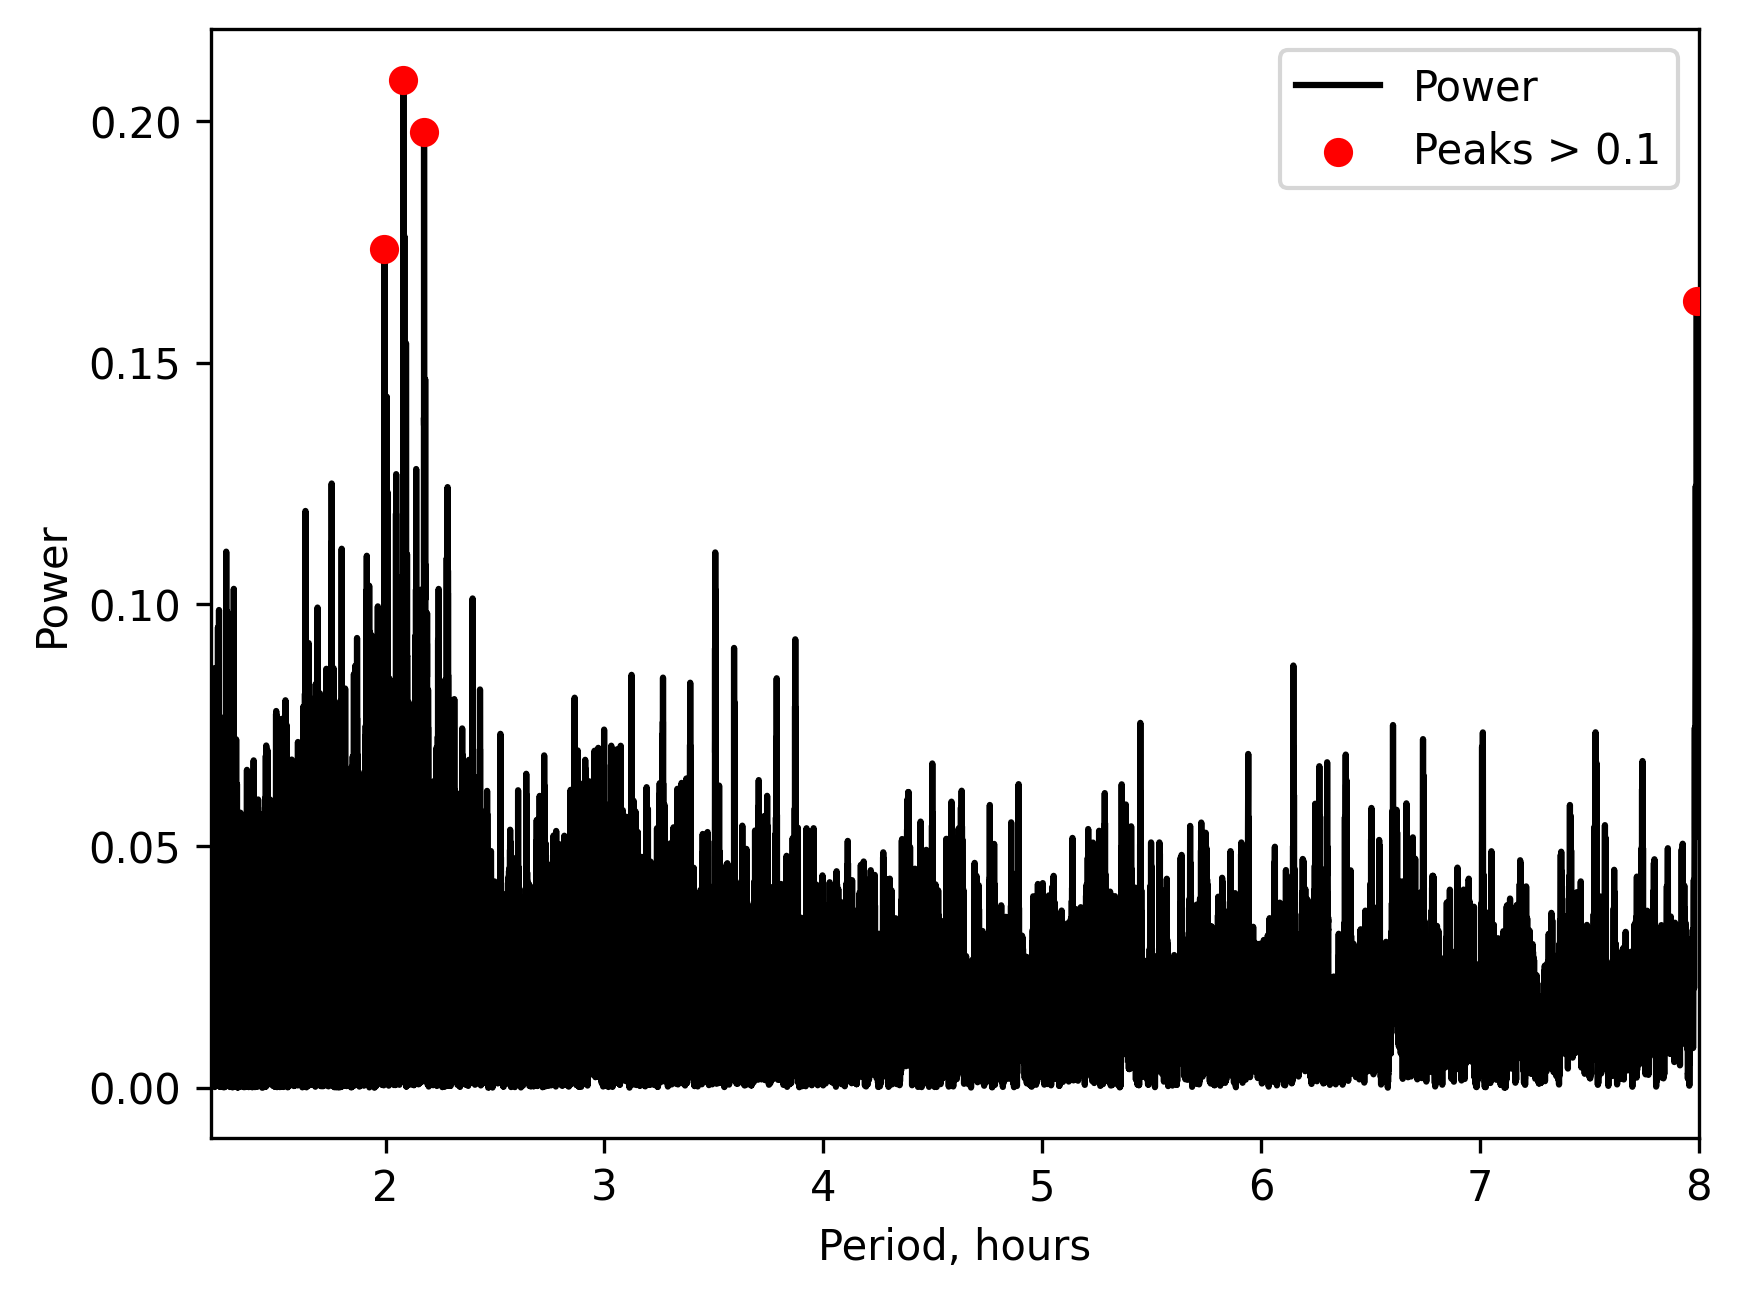

In [314]:
from scipy.signal import find_peaks

plt.figure(dpi = 300)
x_p = frequency
y_p = power

# Only consider peaks above 0.1
peaks, properties = find_peaks(y_p, height=0.15, distance = 10000)

peak_x = x_p[peaks]
peak_y = y_p[peaks]

plt.plot(1/x_p*24, y_p, label="Power", color = "black")
plt.scatter(1/peak_x*24, peak_y, color='red', zorder=5, label="Peaks > 0.1")
plt.xlabel("Period, hours")
plt.ylabel("Power")
plt.xlim((1.2,8))
plt.legend()
plt.savefig(save_figures + "{}_peak_extraction_power_spectrum".format(Asteroid_number))
plt.show()

In [315]:
1/peak_x*24

array([7.9918068 , 2.17551531, 2.0809893 , 1.99358766])

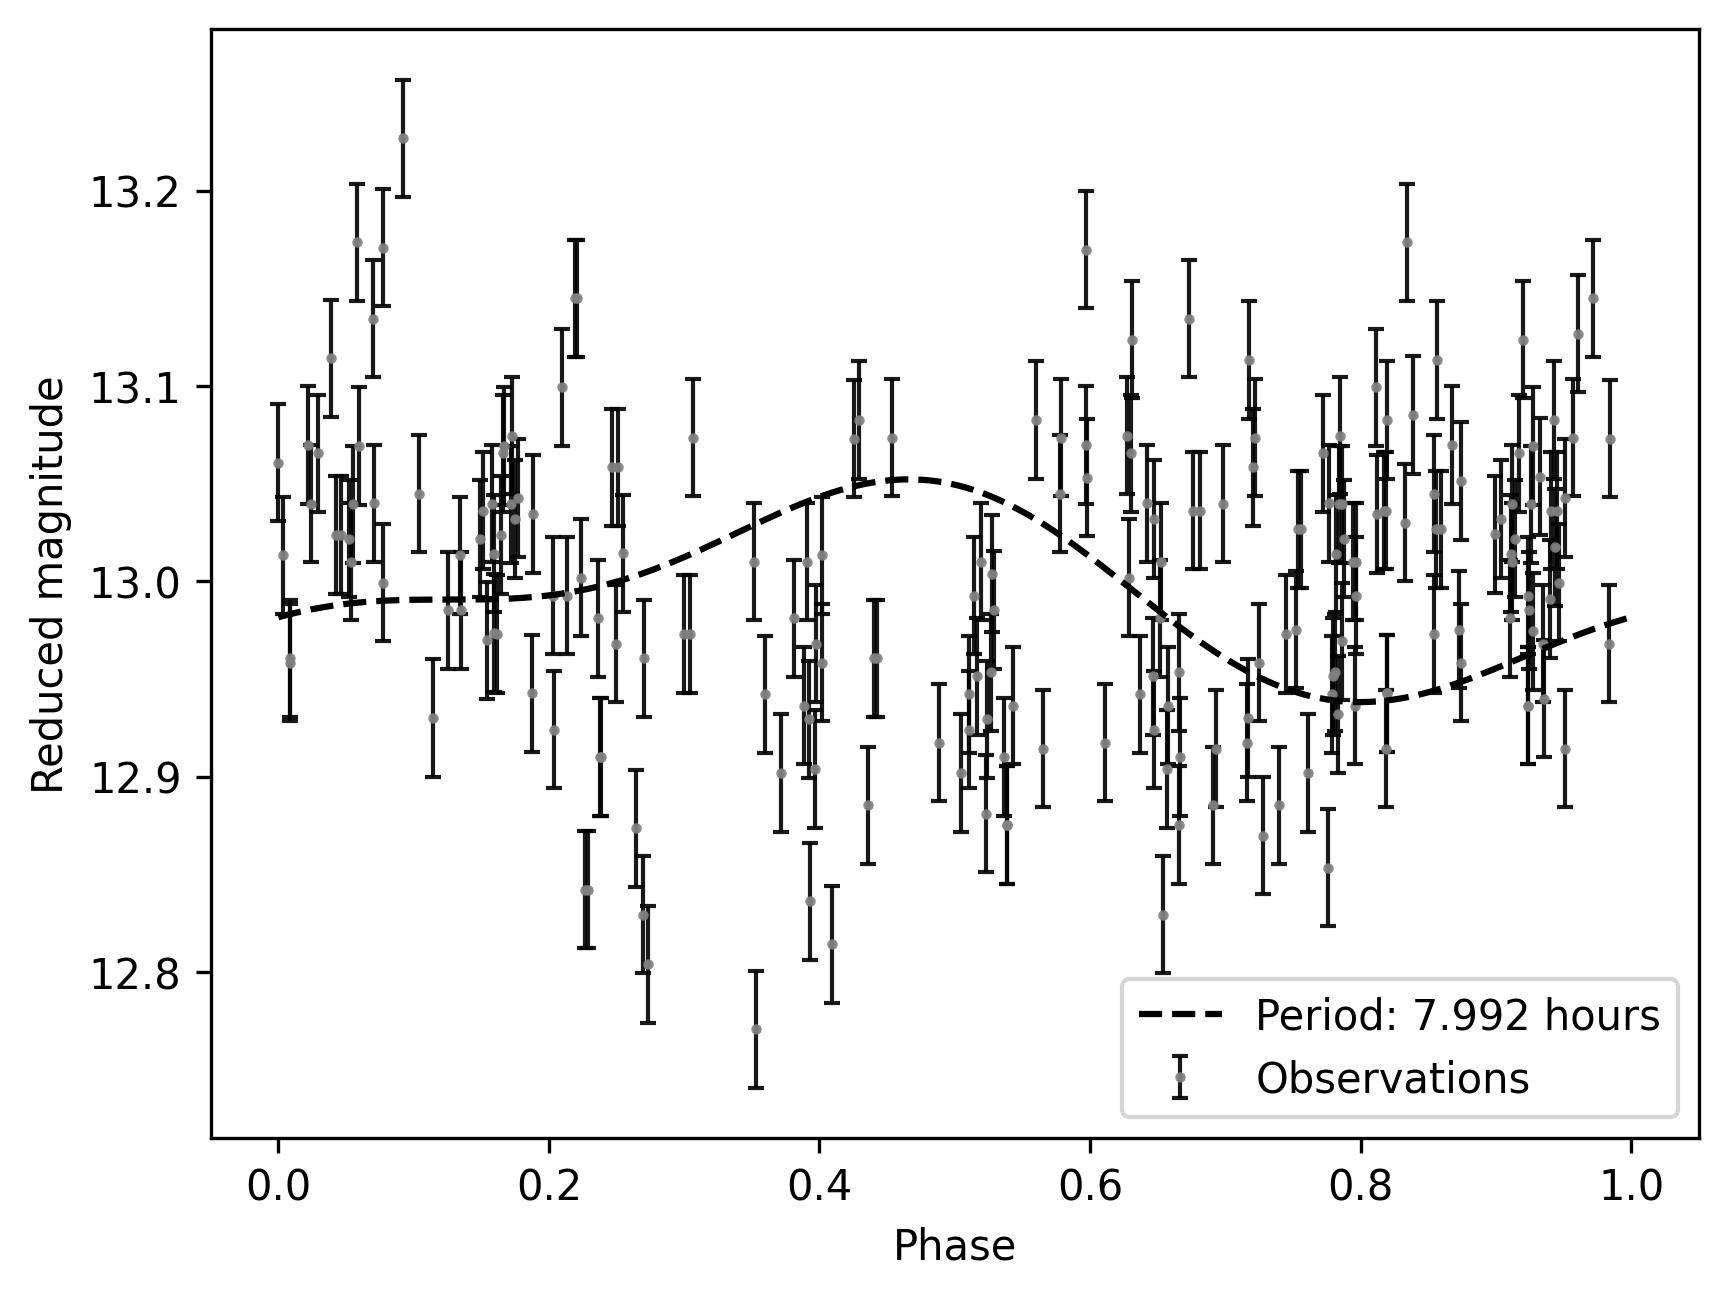

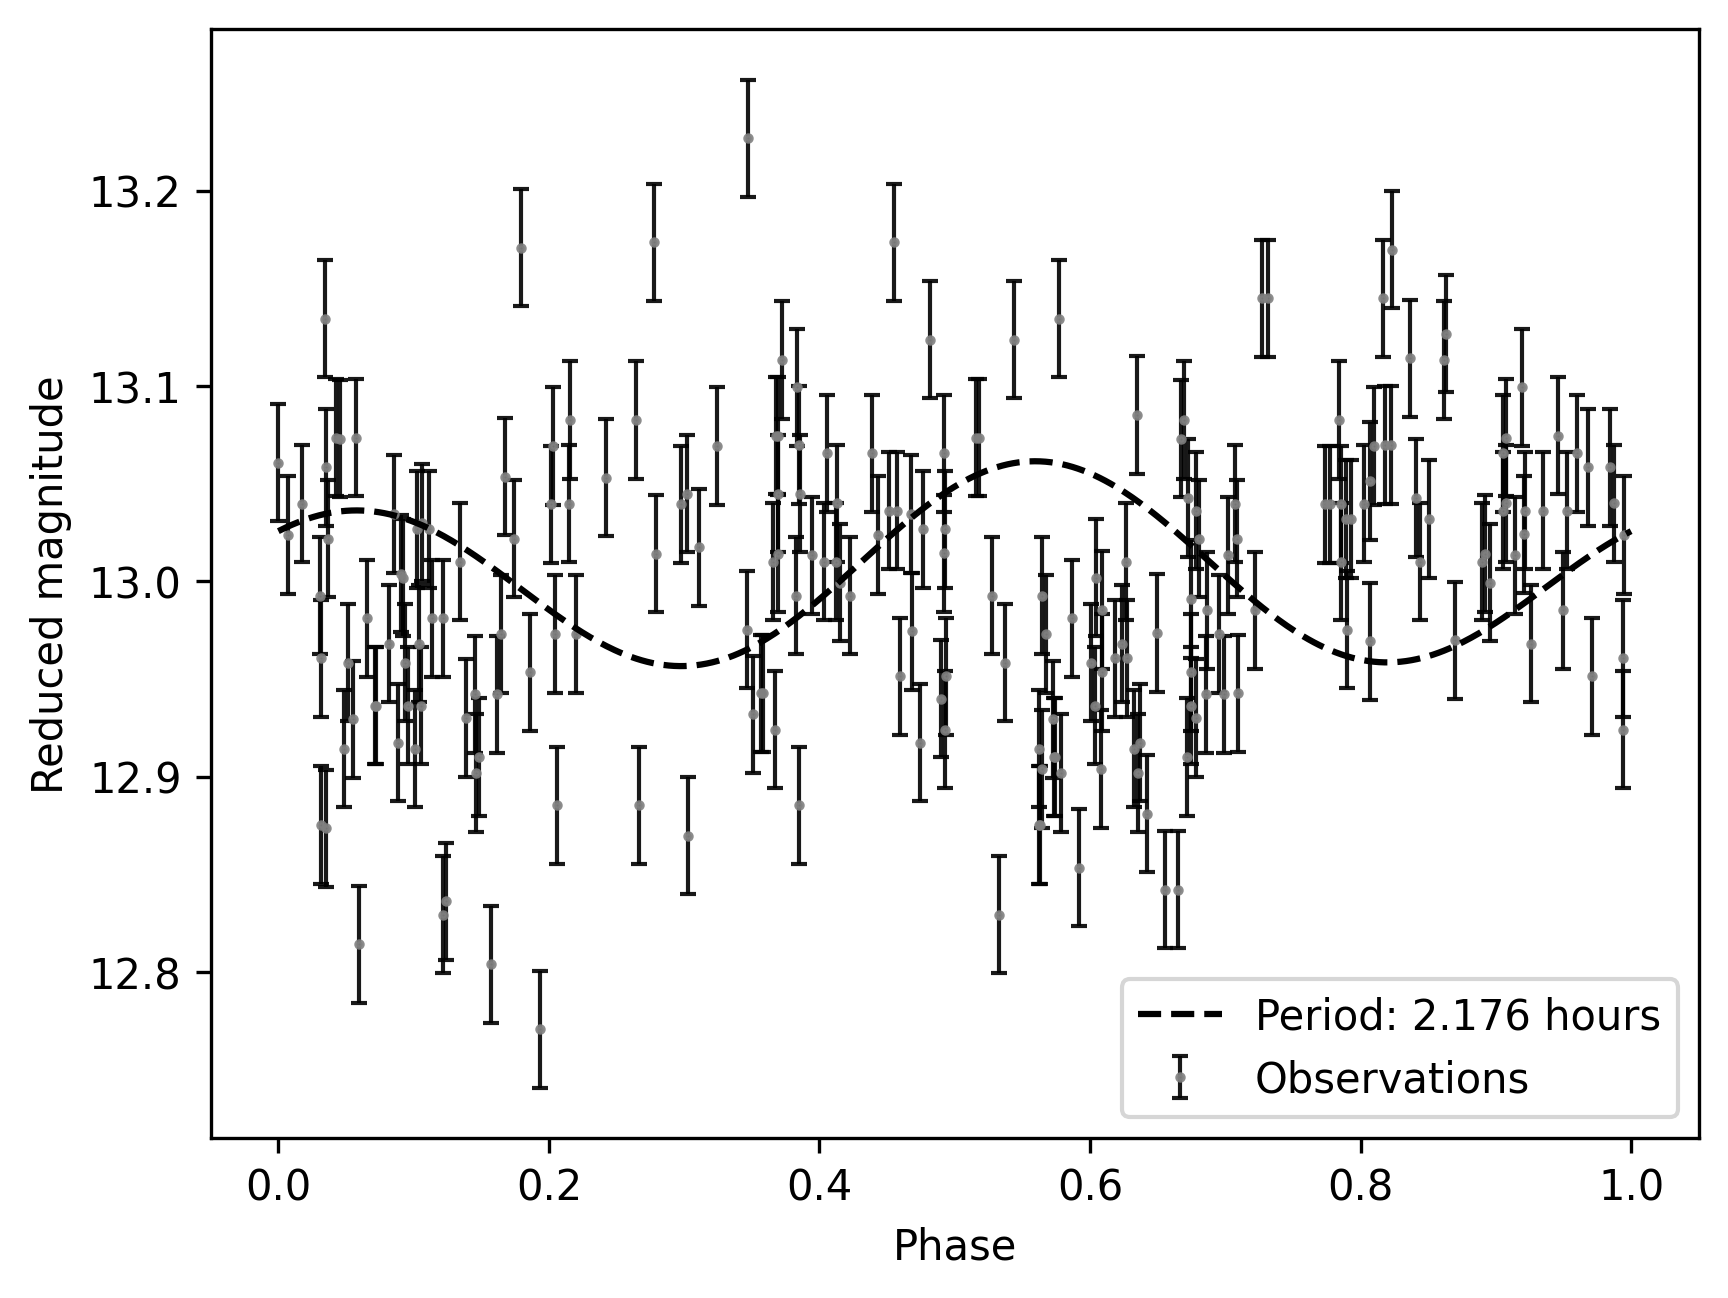

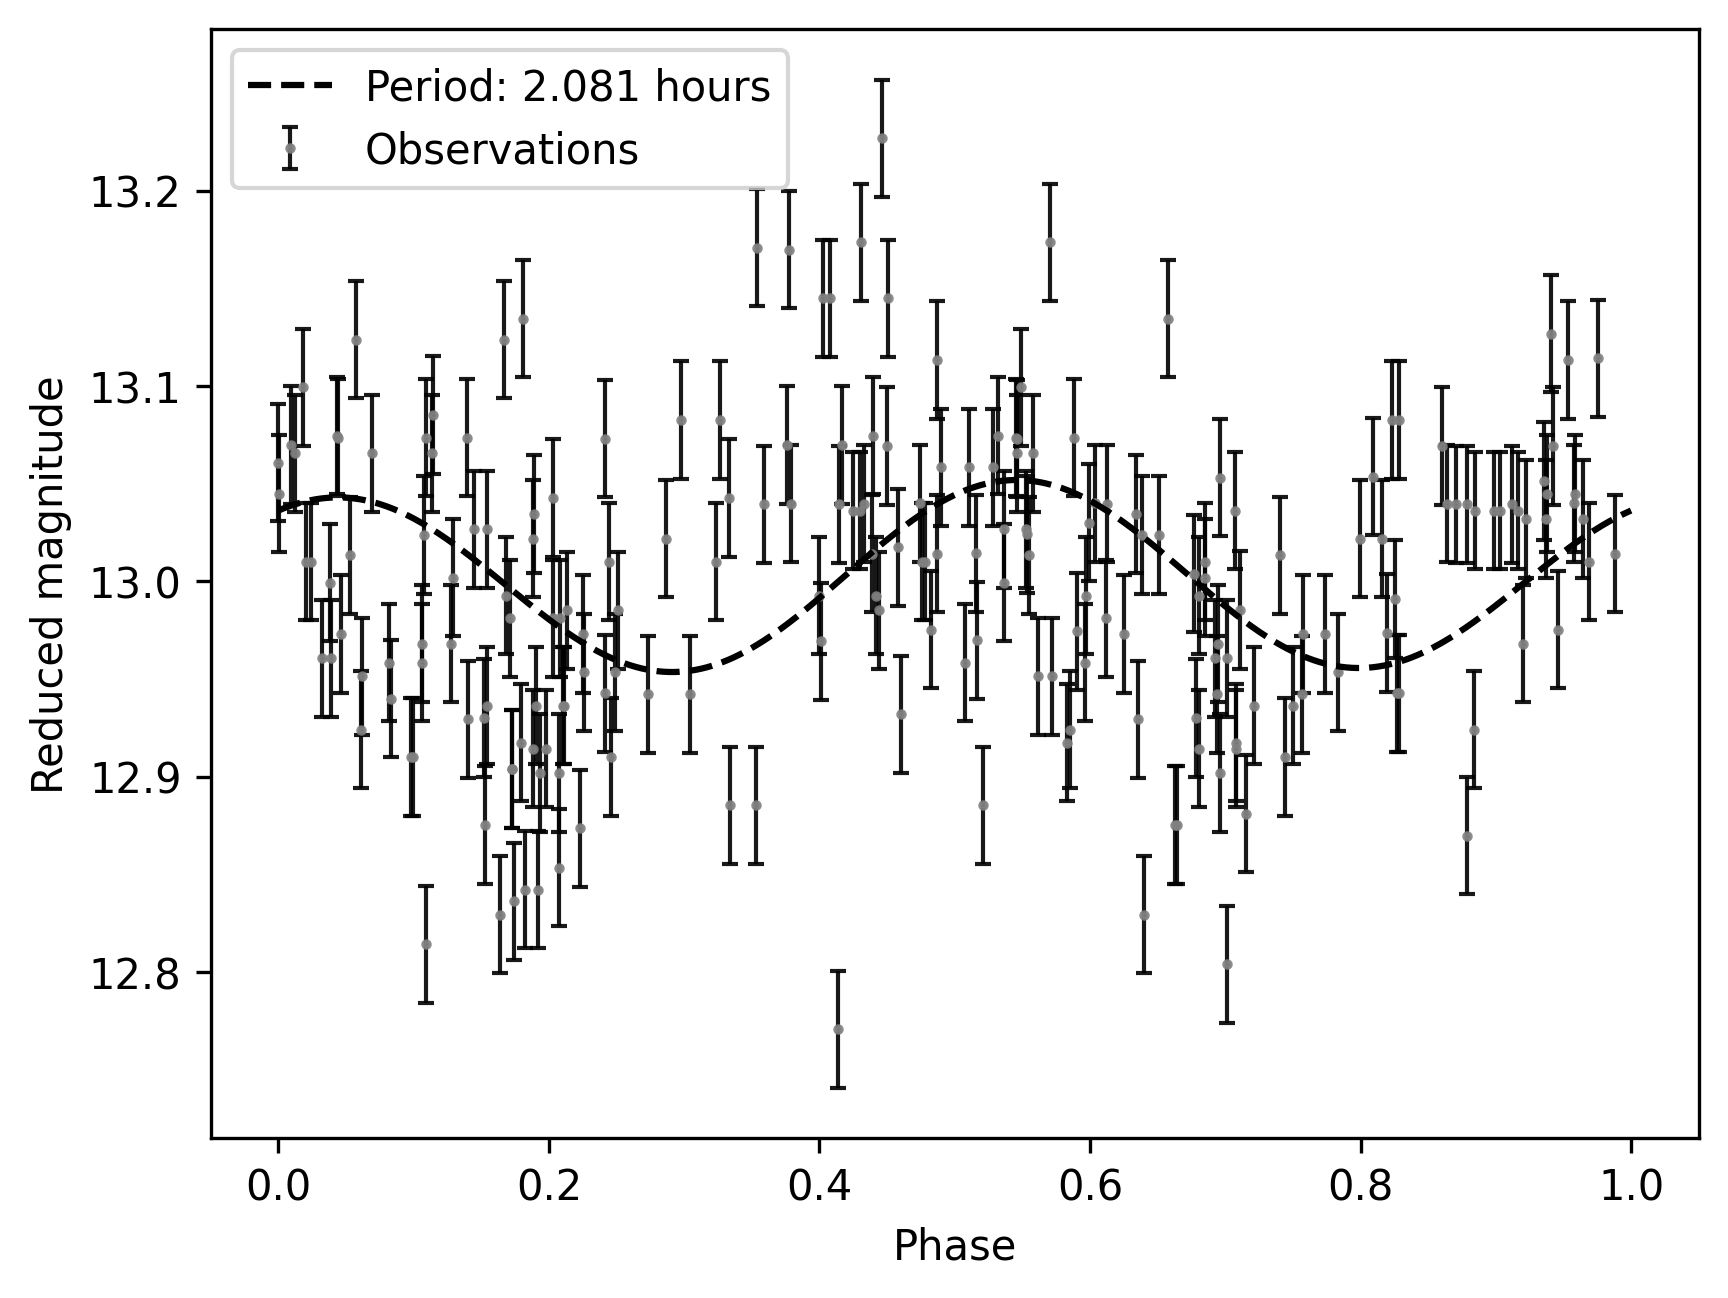

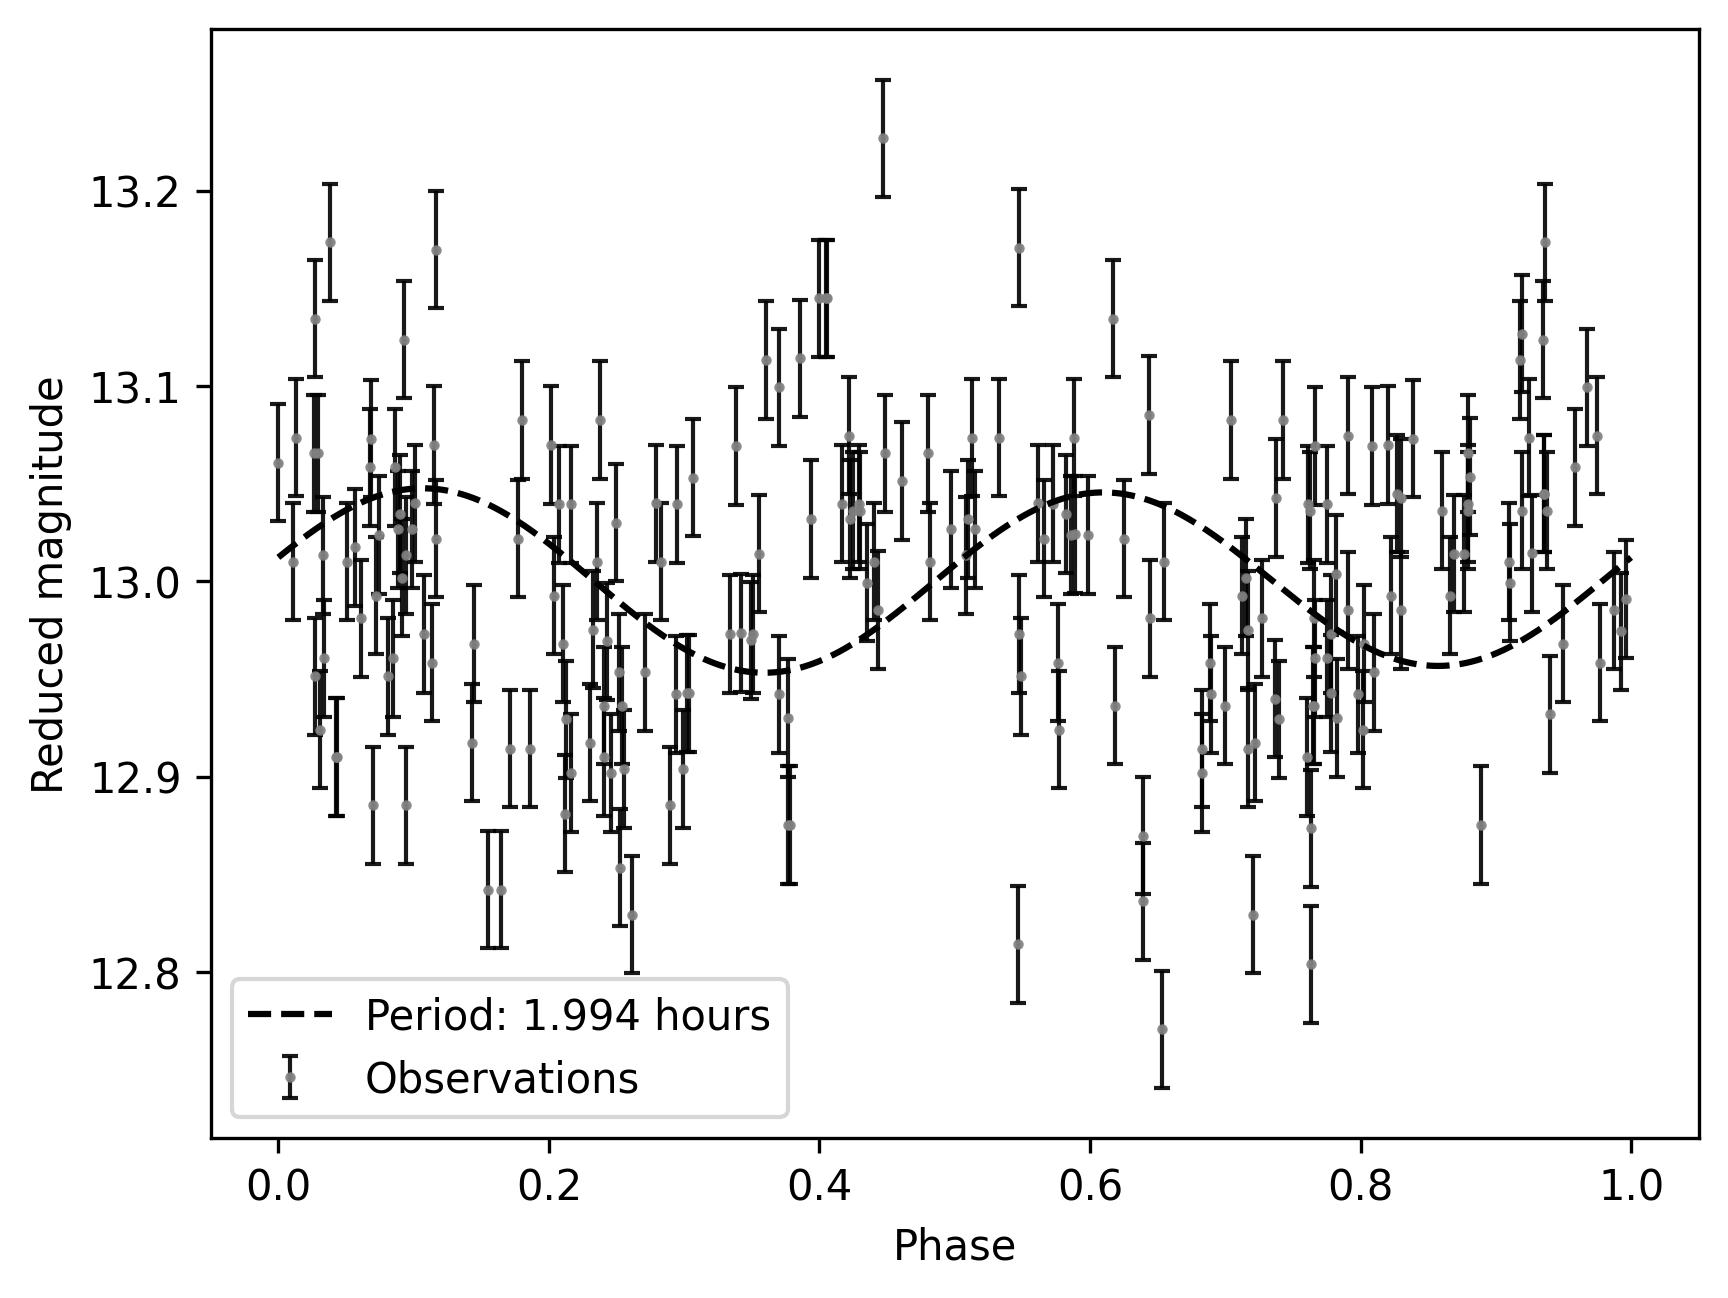

In [316]:
for best_peak in peak_x:
    # best_frequency = 1/(database_period/24) # for testing
    plt.figure(dpi = 300)
    best_frequency = best_peak
    #best_frequency = 1/(23.95423711/24)
    t_fit = np.linspace(0, 1, 500)
    y_fit = ls.model(t_fit/best_frequency, best_frequency)
    
    #
    #xdatas = ((t-t.iloc[0])*best_frequency) % 1
    xdatas = ((ts-ts[0])*best_frequency) % 1
    plt.errorbar(np.array(xdatas), ys, yerr=0.03,  color="gray",
                 ecolor="black", ms=3, fmt=".",
                 capsize=2, elinewidth=1, alpha=0.9, label="Observations", zorder=1)
    
    plt.plot(t_fit, y_fit, "--", c="black",
             label="Period: {:.3f} hours".format(1/best_frequency*24), zorder=2)
    
    plt.legend()
    plt.xlabel("Phase")
    plt.ylabel("Reduced magnitude")
    # plt.ylim((15,20))
    plt.savefig(save_figures + "{}_P={:.3f}_example.jpg".format(Asteroid_number, 1/best_frequency*24))
    #plt.show()

In [227]:
1/peak_x*24

array([47.8036836 , 35.87754921, 23.90115845, 11.95831354])